In [2]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# primarily CDM universe
params = {
    "output": "mTk, mPk",     # matter transfer function, power spectrum
    "P_k_max_h/Mpc": 10.0,    # max k on the  x-axis, usually 1 (?)
    "z_pk": 0.0,              # ?
    "h": 0.67,
   
   
    "Omega_b": 0.005,
    "Omega_cdm": 0.295, #so that they sum to 0.3, the total matter density parameter

    "A_s": 2.1e-9,            # primordial power spectrum amplitude. "how large" density fluctuations were initially    
    "n_s": 0.965,             # spectral index determining shape of primordial spectrum. =1 means scale-invariant, <1 means more power on large scales (small k)
    "YHe": 0.25,              # fraction of He mass over baryon mass. 
    "tau_reio": 0.06,         # ?
}

# Initialize and run CLASS
cosmo = Class()
cosmo.set(params)
cosmo.compute()



### note on the parameters ###

For a mostly CDM-universe:
We can't have a pure CDM universe, because CLASS requires there be photons and baryons. 

We want to set $\Omega_b$ to a small value, but we can't just make it as small as we want. This is because CLASS looks up the parameter YHe from a table of pre-calculated results, which depend on $\Omega_b$, and if $\Omega_b$ is too small it is not in the range of the table. 

We can get around this by fixing YHe ourselves. 

**Question: will this introduce inconsistencies?**

But even then we can't make it too small because there is so conflict with the reionzation simulation. 


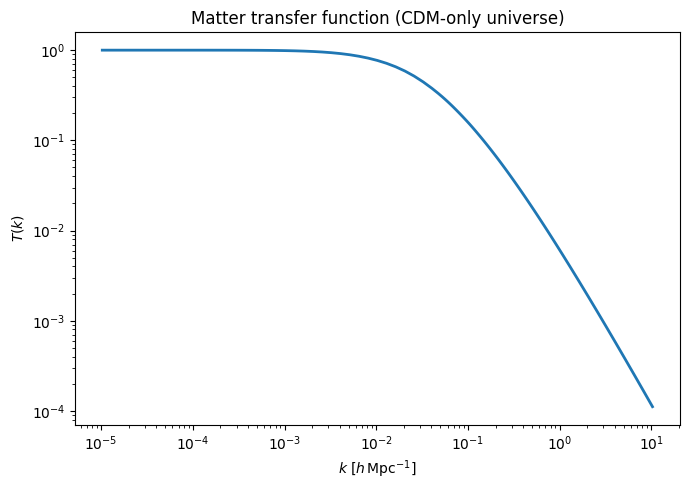

In [31]:
# Total matter transfer function at z=0
tk = cosmo.get_transfer(z=0)
ks = tk["k (h/Mpc)"]           
dtot = tk["d_tot"]     


#??
# Matter transfer function T(k):
T = np.abs(dtot) / ks**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T /= T[0] # normalize to 1 for the matter era entries




# Plot
plt.figure(figsize=(7, 5))
plt.loglog(ks, T, lw=2)
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$T(k)$")
plt.title("Matter transfer function (CDM-only universe)")
plt.tight_layout()
plt.show()


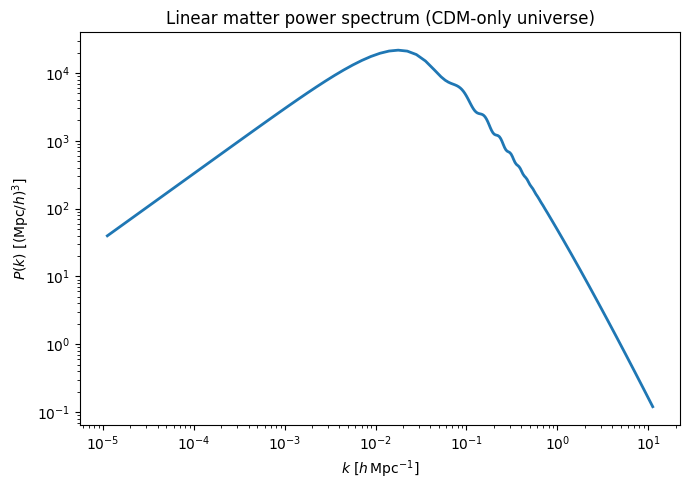

In [15]:
# Linear (total) matter power spectrum at z = 0
h = params["h"]


Pk = np.array([cosmo.pk_lin(k_var * h, 0.0) for k_var in ks]) * h**3  # [(Mpc/h)^3]

plt.figure(figsize=(7, 5))
plt.loglog(ks, Pk, lw=2)
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k) \ [(\mathrm{Mpc}/h)^3]$")
plt.title("Linear matter power spectrum (CDM-only universe)")
plt.tight_layout()
plt.show()

#### note on units ####

classy.pk_lin wants k in 1/Mpc and returns P in Mpc^3. the k array is in units of
h/Mpc, so to convert, multiply by h: 
$$ x \ [h/Mpc] = xh \ [1/Mpc]$$

It also outputs the power spectrum in units of Mpc^3, so we multiply by h^3 
to get in units of (Mpc / h)^3:
$$x \ [Mpc^3] = x h^3 \ [(Mpc / h)^3]$$

In [ ]:
# Clean up CLASS internals
cosmo.struct_cleanup()
cosmo.empty()